# Figure: VIMFC and 850-hPa MFC Response - Model Only (Option 1)

This notebook visualizes the model-only (Option 1: $q' \mathbf{v}'$) convergence and moisture flux vectors.
- **(a–c)** Vertically Integrated Moisture Flux Convergence (VIMFC) and VIMF vectors.
- **(d–f)** 850-hPa Moisture Flux Convergence (MFC850) and 850-hPa moisture flux vectors.

It loads the precalculated NetCDF dataset `convergence_vimfc_850_model_only.nc`.
Layout, fonts, and styling follow the Fig5 overlay design.


In [1]:
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.ticker import FuncFormatter
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

# -----------------------------------------------------------------------------
# USER TWEAK SECTION
# -----------------------------------------------------------------------------
PLOT_FONTSIZE = 22
FIGURE_WIDTH, FIGURE_HEIGHT, FIGURE_DPI = 30, 18, 200

# Subplot Grid & Margins
GRID_LEFT, GRID_RIGHT = 0.045, 0.985
GRID_TOP, GRID_BOTTOM = 0.94, 0.10
GRID_WSPACE = 0.12
GRID_HSPACE = 0.35

TITLE_PAD = 16

# Quiver settings for Model Only (Option 1):
# Max speed VIMF ~ 11 kg m^-1 s^-1 -> scale 120, key 5
# Max speed MF850 ~ 0.004 kg kg^-1 m s^-1 -> scale 0.045, key 0.002
VIMF_SCALE = 120
VIMF_KEY_MAG = 5
VIMF_KEY_LABEL = r'5 kg m$^{-1}$ s$^{-1}$'

MF850_SCALE = 0.045
MF850_KEY_MAG = 0.002
MF850_KEY_LABEL = r'0.002 kg kg$^{-1}$ m s$^{-1}$'

# Quiver key and box geometry (axes coordinates)
WIND_KEY_X, WIND_KEY_Y = 0.94, 0.94
WIND_KEY_BOX_LEFT = 0.52
WIND_KEY_BOX_BOTTOM = 0.8975
WIND_KEY_BOX_WIDTH = 0.47
WIND_KEY_BOX_HEIGHT = 0.10

# Colormaps
CMAP_ABS = 'bwr'
CMAP_DIFF = 'BrBG'

# Row 1 (VIMFC): Abs [-10, 10], Diff [-5, 5]
R1_LEVELS_ABS = np.arange(-10.0, 10.0001, 1.0)
R1_NORM_ABS = mcolors.Normalize(vmin=-10.0, vmax=10.0)
R1_TICKS_ABS = [-10, -5, 0, 5, 10]

R1_LEVELS_DIFF = np.arange(-5.0, 5.0001, 0.5)
R1_NORM_DIFF = mcolors.Normalize(vmin=-5.0, vmax=5.0)
R1_TICKS_DIFF = [-5, -2.5, 0, 2.5, 5]

# Row 2 (MFC850): Abs [-5, 5], Diff [-2.5, 2.5]
R2_LEVELS_ABS = np.arange(-5.0, 5.0001, 0.5)
R2_NORM_ABS = mcolors.Normalize(vmin=-5.0, vmax=5.0)
R2_TICKS_ABS = [-5, -2.5, 0, 2.5, 5]

R2_LEVELS_DIFF = np.arange(-2.5, 2.5001, 0.25)
R2_NORM_DIFF = mcolors.Normalize(vmin=-2.5, vmax=2.5)
R2_TICKS_DIFF = [-2.5, -1.25, 0, 1.25, 2.5]

# Colorbar settings
COLORBAR_HEIGHT = 0.018
ROW1_COLORBAR_OFFSET = 0.065
ROW2_COLORBAR_OFFSET = 0.065
COLORBAR_LABELPAD = 10

# Matplotlib global typography
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': PLOT_FONTSIZE,
    'axes.titlesize': PLOT_FONTSIZE,
    'axes.labelsize': PLOT_FONTSIZE,
    'xtick.labelsize': PLOT_FONTSIZE,
    'ytick.labelsize': PLOT_FONTSIZE,
    'axes.unicode_minus': False,
})

# Path configuration
WORKING_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/ConvergenceModel')
DATA_PATH = WORKING_DIR / 'convergence_vimfc_850_model_only.nc'
OUTPUT_PNG = WORKING_DIR / 'fig_convergence_vimfc_850_model_only.png'

print(f'Loading data from: {DATA_PATH}')


Loading data from: /Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/ConvergenceModel/convergence_vimfc_850_model_only.nc


In [2]:
ds = xr.open_dataset(DATA_PATH)

def decode_case(val):
    if isinstance(val, bytes):
        return val.decode('utf-8')
    return str(val)

case_names = [decode_case(c) for c in ds['case'].values]
ds = ds.assign_coords(case=('case', case_names))

print('Available cases:', list(ds.case.values))

# Extract cases
ctrl = ds.sel(case='CTRL')
exp = ds.sel(case='EXP_B_S-123')
diff = ds.sel(case='EXP_minus_CTRL')

# Row 1: VIMFC & VIMF vectors
row1_data = [
    (ctrl['VIMFC'] * 1e6, ctrl['VIMF_u'], ctrl['VIMF_v']),
    (exp['VIMFC'] * 1e6, exp['VIMF_u'], exp['VIMF_v']),
    (diff['VIMFC'] * 1e6, diff['VIMF_u'], diff['VIMF_v']),
]

# Row 2: MFC850 & MF_850 vectors (scaled by 1e9)
row2_data = [
    (ctrl['MFC_850'] * 1e9, ctrl['MF_850_u'], ctrl['MF_850_v']),
    (exp['MFC_850'] * 1e9, exp['MF_850_u'], exp['MF_850_v']),
    (diff['MFC_850'] * 1e9, diff['MF_850_u'], diff['MF_850_v']),
]

row1_titles = [
    r'(a) Respons CTRL (VIMFC)',
    r'(b) Respons EXP_B_S-123 (VIMFC)',
    r'(c) EXP_B_S-123 − CTRL (VIMFC)',
]

row2_titles = [
    r'(d) Respons CTRL (MFC850)',
    r'(e) Respons EXP_B_S-123 (MFC850)',
    r'(f) EXP_B_S-123 − CTRL (MFC850)',
]
print('Data prepared successfully.')


Available cases: [np.str_('CTRL'), np.str_('EXP_B_S-123'), np.str_('EXP_minus_CTRL')]
Data prepared successfully.


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

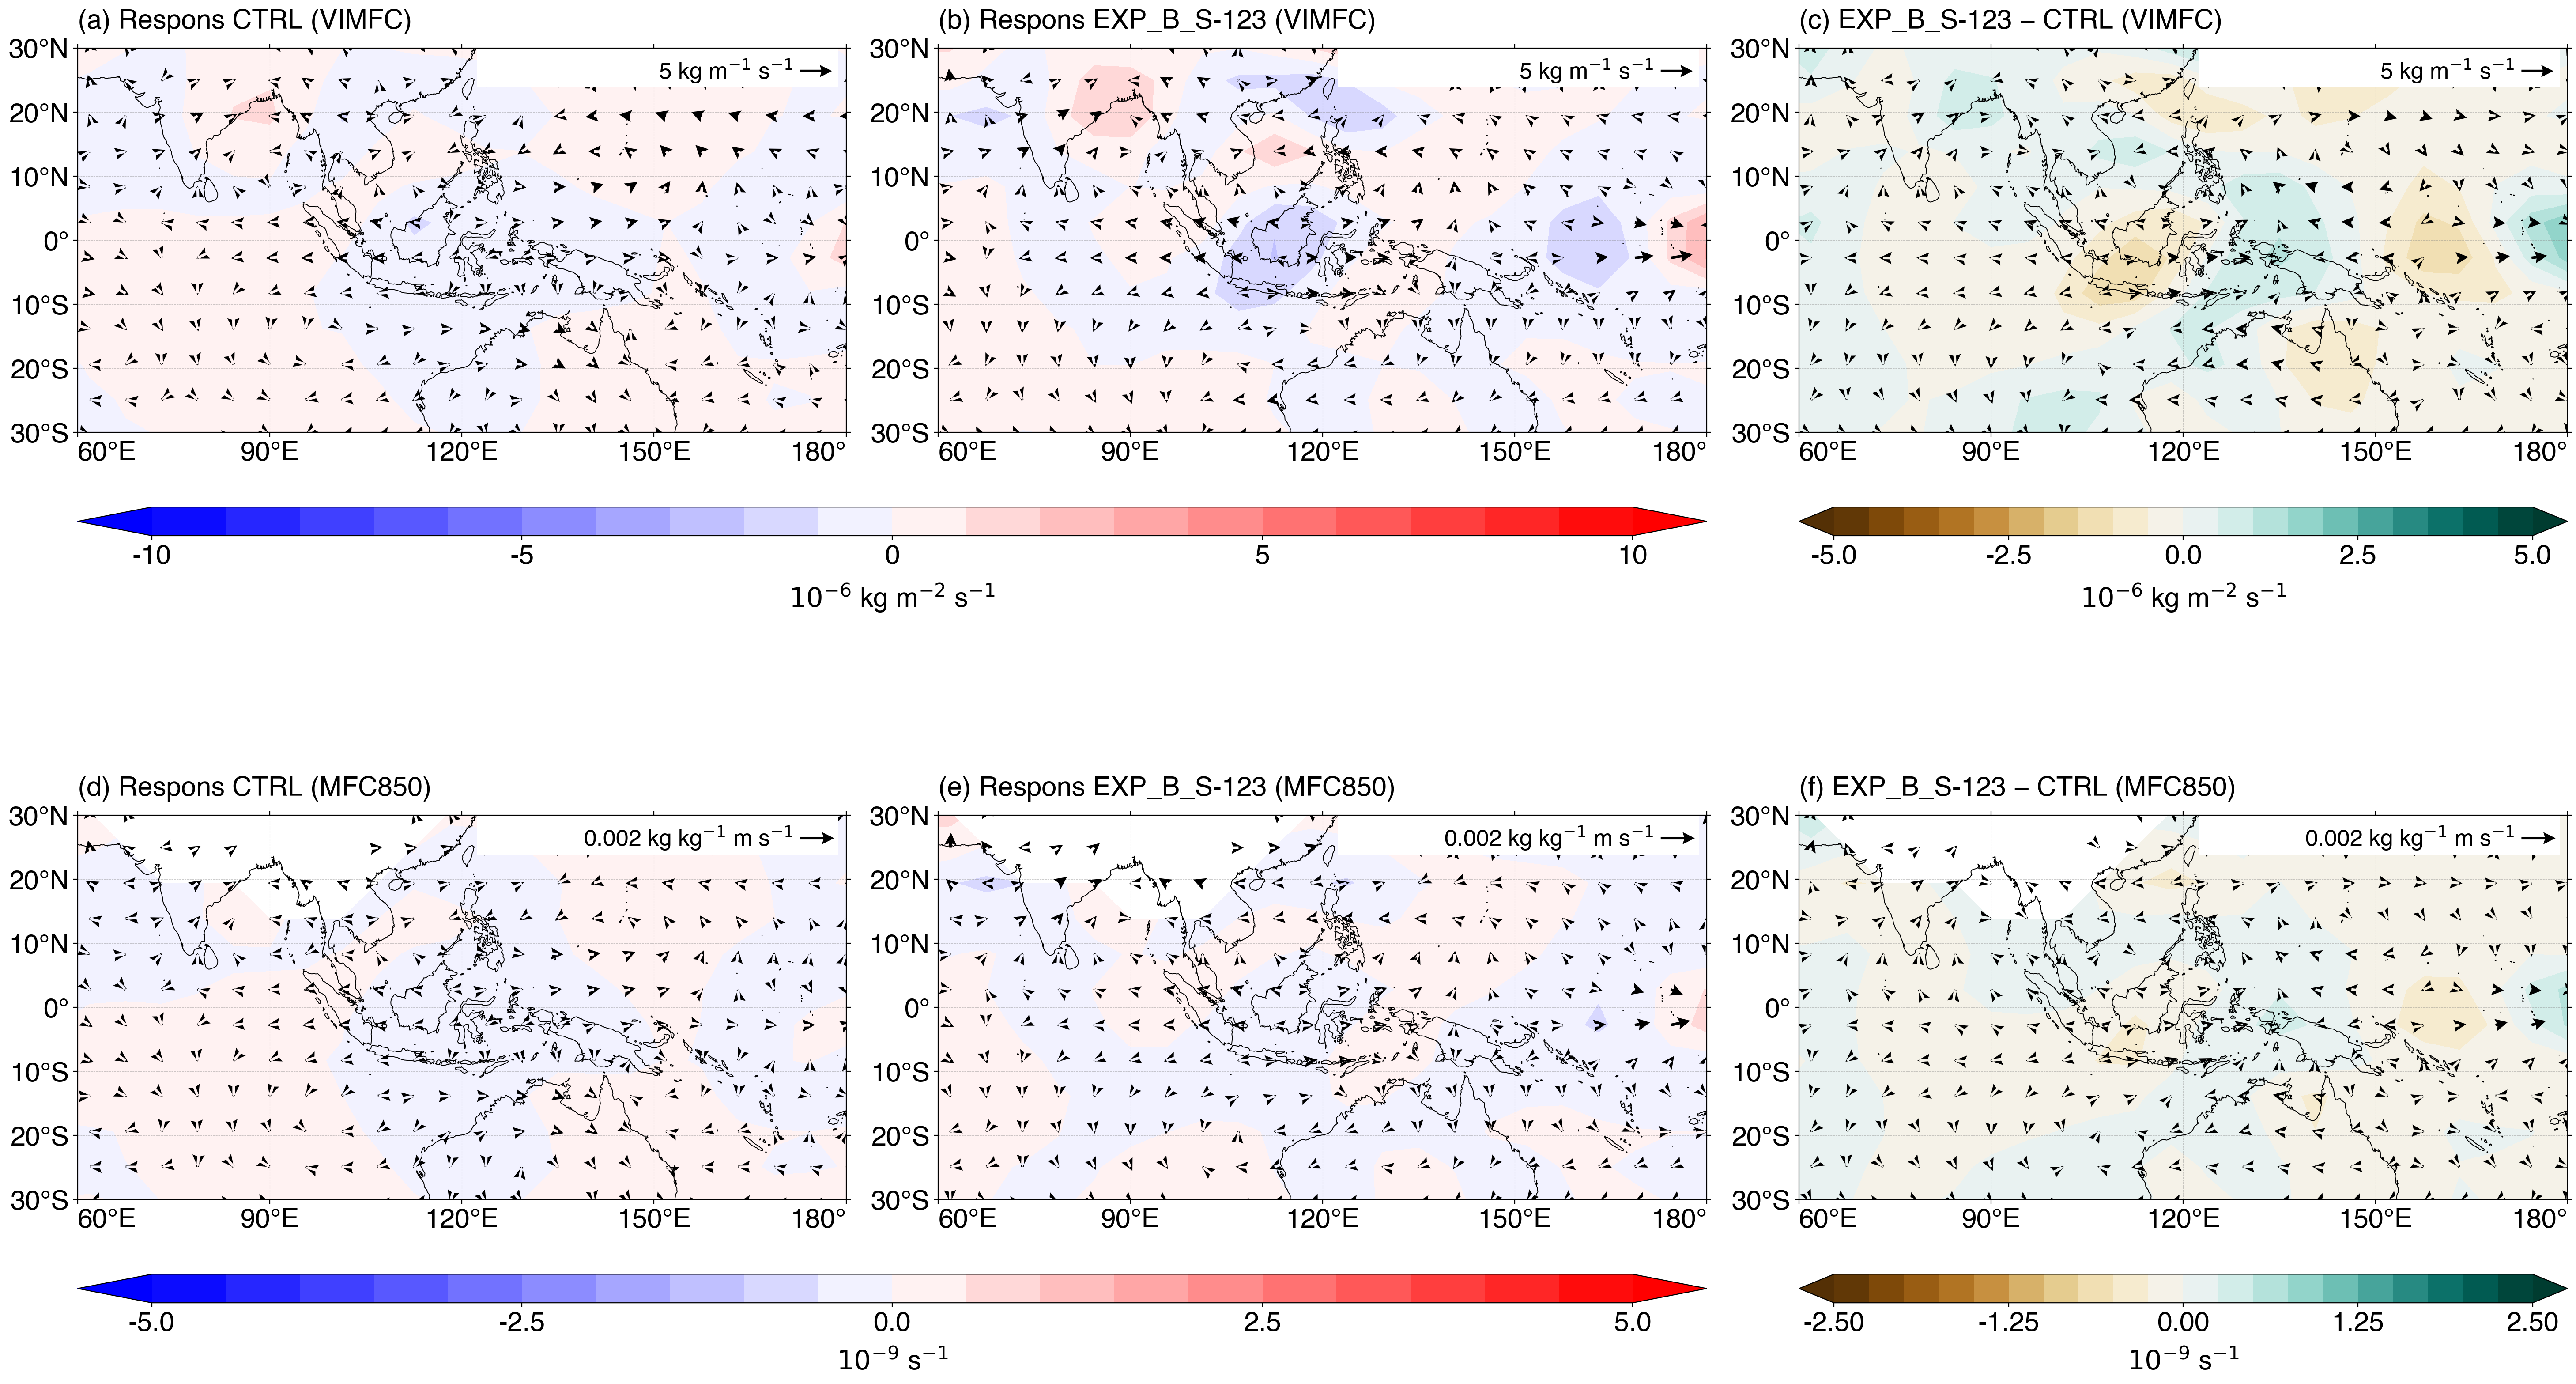

Successfully saved figure to /Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/ConvergenceModel/fig_convergence_vimfc_850_model_only.png


In [3]:
# Helper styling functions matching Fig5
def add_map_style(ax, extent, xticks, yticks):
    ax.coastlines(resolution='50m', color='black', linewidth=0.7, zorder=3)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
    ax.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
    ax.tick_params(direction='out', top=True, right=True, labelsize=PLOT_FONTSIZE)
    ax.gridlines(xlocs=xticks, ylocs=yticks, draw_labels=False, linewidth=0.4,
                 color='gray', alpha=0.4, linestyle='--')

def align_endpoint_tick_labels(ax, first_label, last_label):
    for label in ax.get_xticklabels():
        if first_label in label.get_text():
            label.set_ha('left')
        elif last_label in label.get_text():
            label.set_ha('right')

fig = plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=FIGURE_DPI)
gs = fig.add_gridspec(2, 3, left=GRID_LEFT, right=GRID_RIGHT, bottom=GRID_BOTTOM, top=GRID_TOP,
                      wspace=GRID_WSPACE, hspace=GRID_HSPACE)

axes_row1 = [fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree(central_longitude=180)) for i in range(3)]
axes_row2 = [fig.add_subplot(gs[1, i], projection=ccrs.PlateCarree(central_longitude=180)) for i in range(3)]

extent = [60, 180, -30, 30]
xticks = [60, 90, 120, 150, 180]
yticks = [-30, -20, -10, 0, 10, 20, 30]

row1_contours = []
row2_contours = []

# --- ROW 1: VIMFC ---
for i, (ax, (fc, u, v), title) in enumerate(zip(axes_row1, row1_data, row1_titles)):
    vals, lons = add_cyclic_point(fc.values, coord=ds.lon.values)
    cmap = CMAP_ABS if i < 2 else CMAP_DIFF
    lvls = R1_LEVELS_ABS if i < 2 else R1_LEVELS_DIFF
    norm = R1_NORM_ABS if i < 2 else R1_NORM_DIFF
    cf = ax.contourf(lons, ds.lat.values, vals,
                     levels=lvls, norm=norm, cmap=cmap,
                     transform=ccrs.PlateCarree(), extend='both')
    row1_contours.append(cf)
    add_map_style(ax, extent, xticks, yticks)
    
    # Vector quiver matching Fig5 quiver configuration & scale
    lon2d, lat2d = np.meshgrid(ds.lon.values, ds.lat.values)
    q = ax.quiver(lon2d, lat2d, u.values, v.values, transform=ccrs.PlateCarree(),
                  color='black', scale=VIMF_SCALE, width=0.0035,
                  headwidth=8 * (0.0020 / 0.0035),
                  headlength=8 * (0.0020 / 0.0035),
                  headaxislength=7 * (0.0020 / 0.0035),
                  minshaft=0, minlength=0, zorder=4)
    
    # Key box & Quiverkey
    key_box = mpatches.Rectangle((WIND_KEY_BOX_LEFT, WIND_KEY_BOX_BOTTOM),
                                 WIND_KEY_BOX_WIDTH, WIND_KEY_BOX_HEIGHT, transform=ax.transAxes,
                                 facecolor='white', edgecolor='none', alpha=1.0, zorder=5)
    ax.add_patch(key_box)
    qk = ax.quiverkey(q, X=WIND_KEY_X, Y=WIND_KEY_Y, U=VIMF_KEY_MAG, label=VIMF_KEY_LABEL,
                      labelpos='W', coordinates='axes', fontproperties={'size': PLOT_FONTSIZE * 0.85}, labelsep=0.08)
    qk.set_zorder(6)
    qk.text.set_zorder(7)
    
    ax.set_title(title, loc='left', pad=TITLE_PAD, weight='bold', fontsize=PLOT_FONTSIZE)

# --- ROW 2: MFC850 ---
for i, (ax, (fc, u, v), title) in enumerate(zip(axes_row2, row2_data, row2_titles)):
    vals, lons = add_cyclic_point(fc.values, coord=ds.lon.values)
    cmap = CMAP_ABS if i < 2 else CMAP_DIFF
    lvls = R2_LEVELS_ABS if i < 2 else R2_LEVELS_DIFF
    norm = R2_NORM_ABS if i < 2 else R2_NORM_DIFF
    cf = ax.contourf(lons, ds.lat.values, vals,
                     levels=lvls, norm=norm, cmap=cmap,
                     transform=ccrs.PlateCarree(), extend='both')
    row2_contours.append(cf)
    add_map_style(ax, extent, xticks, yticks)
    
    # Vector quiver matching Fig5 quiver configuration & scale
    lon2d, lat2d = np.meshgrid(ds.lon.values, ds.lat.values)
    q = ax.quiver(lon2d, lat2d, u.values, v.values, transform=ccrs.PlateCarree(),
                  color='black', scale=MF850_SCALE, width=0.0035,
                  headwidth=8 * (0.0020 / 0.0035),
                  headlength=8 * (0.0020 / 0.0035),
                  headaxislength=7 * (0.0020 / 0.0035),
                  minshaft=0, minlength=0, zorder=4)
    
    # Key box & Quiverkey
    key_box = mpatches.Rectangle((WIND_KEY_BOX_LEFT, WIND_KEY_BOX_BOTTOM),
                                 WIND_KEY_BOX_WIDTH, WIND_KEY_BOX_HEIGHT, transform=ax.transAxes,
                                 facecolor='white', edgecolor='none', alpha=1.0, zorder=5)
    ax.add_patch(key_box)
    qk = ax.quiverkey(q, X=WIND_KEY_X, Y=WIND_KEY_Y, U=MF850_KEY_MAG, label=MF850_KEY_LABEL,
                      labelpos='W', coordinates='axes', fontproperties={'size': PLOT_FONTSIZE * 0.85}, labelsep=0.08)
    qk.set_zorder(6)
    qk.text.set_zorder(7)
    
    ax.set_title(title, loc='left', pad=TITLE_PAD, weight='bold', fontsize=PLOT_FONTSIZE)

# Ensure labels don't get clipped
fig.canvas.draw()
for ax in axes_row1 + axes_row2:
    align_endpoint_tick_labels(ax, '60°E', '180°')

# --- Colorbars ---
def cbar_axes(ax_left, ax_right, y_offset):
    left, right = ax_left.get_position().x0, ax_right.get_position().x1
    y = ax_left.get_position().y0 - y_offset
    return fig.add_axes([left, y, right - left, COLORBAR_HEIGHT])

# Row 1 colorbars (VIMFC)
r1_abs_cbar = fig.colorbar(row1_contours[0], cax=cbar_axes(axes_row1[0], axes_row1[1], ROW1_COLORBAR_OFFSET),
                           orientation='horizontal', ticks=R1_TICKS_ABS, extend='both')
r1_diff_cbar = fig.colorbar(row1_contours[2], cax=cbar_axes(axes_row1[2], axes_row1[2], ROW1_COLORBAR_OFFSET),
                            orientation='horizontal', ticks=R1_TICKS_DIFF, extend='both')

r1_abs_cbar.set_label(r'$10^{-6}$ kg m$^{-2}$ s$^{-1}$', fontsize=PLOT_FONTSIZE, labelpad=COLORBAR_LABELPAD)
r1_diff_cbar.set_label(r'$10^{-6}$ kg m$^{-2}$ s$^{-1}$', fontsize=PLOT_FONTSIZE, labelpad=COLORBAR_LABELPAD)

# Row 2 colorbars (MFC850)
r2_abs_cbar = fig.colorbar(row2_contours[0], cax=cbar_axes(axes_row2[0], axes_row2[1], ROW2_COLORBAR_OFFSET),
                           orientation='horizontal', ticks=R2_TICKS_ABS, extend='both')
r2_diff_cbar = fig.colorbar(row2_contours[2], cax=cbar_axes(axes_row2[2], axes_row2[2], ROW2_COLORBAR_OFFSET),
                            orientation='horizontal', ticks=R2_TICKS_DIFF, extend='both')

r2_abs_cbar.set_label(r'$10^{-9}$ s$^{-1}$', fontsize=PLOT_FONTSIZE, labelpad=COLORBAR_LABELPAD)
r2_diff_cbar.set_label(r'$10^{-9}$ s$^{-1}$', fontsize=PLOT_FONTSIZE, labelpad=COLORBAR_LABELPAD)

for cbar in [r1_abs_cbar, r1_diff_cbar, r2_abs_cbar, r2_diff_cbar]:
    cbar.ax.tick_params(labelsize=PLOT_FONTSIZE)

fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')
plt.show()
print(f'Successfully saved figure to {OUTPUT_PNG}')
